# 🖼️ Participant Starter: Build your ISU Translator (Track A)

This notebook provides a complete participant workflow for Track A: configure the environment, inspect the provided simulated scenes and auxiliary channels, run an image-translation technique, and write the submission folder in the expected format.

Your task is to implement the `translate(simulated_image, stem, label, **kwargs)` function. It receives one simulated RGB image (and optionally its label and auxiliary channel data such as segmentation, canny edges, or depth) and must return a translated image that looks real while keeping the same objects and geometry as the simulated source.

See the root `README.md` and `track_a/README.md` for the feature definitions, evaluation metrics, and submission requirements (file naming, allowed formats, what you may and may not change).

## 1. ⚙️ Configure the environment

Install the Track A dependencies before running the notebook:

```bash
pip install -r track_a/requirements.txt
```

Select the Track A virtual-environment kernel (`.venv` or `venv`) before executing the cells below.

### 🚀 Optional: GPU support (NVIDIA / CUDA)

On Windows (and on some Linux setups), `pip install torch` installs a **CPU-only** build, so models such as SAM, Moondream, or Qwen fall back to the CPU (you will see `Device set to use cpu`). To use an NVIDIA GPU, reinstall `torch` and `torchvision` from PyTorch's CUDA wheel index inside the same environment:

```bash
# Example for CUDA 13.0; pick the matching command for your OS and driver at
# https://pytorch.org/get-started/locally/
pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu130
```

Notes:

- Check your driver with `nvidia-smi`; the CUDA version it reports must be at least the one in the index URL (e.g. `cu130` needs CUDA 13.0 or newer).
- Not every CUDA index has wheels for every PyTorch release. If pip installs an older or mismatched version, try another index (e.g. `cu128`, `cu126`) or pin matching versions such as `torch==X torchvision==Y`.
- Shut down all running notebook kernels before reinstalling. On Windows, loaded torch files are locked and the reinstall fails with `Access denied`.
- Restart the kernel afterwards and check that the GPU is visible:

```python
import torch
print(torch.__version__, torch.cuda.is_available())  # e.g. 2.14.0+cu130 True
```

Apple Silicon Macs need no extra install; the standard `torch` build supports the `mps` device.

In [10]:
import sys
from pathlib import Path

VENV_PYTHON = Path(sys.executable).resolve()
if Path(sys.prefix).resolve() == Path(sys.base_prefix).resolve():
    raise RuntimeError(
        'Select the Track A virtual-environment kernel (.venv or venv) and restart the notebook.'
    )

print('Using environment:', VENV_PYTHON)

Using environment: C:\Users\levia\Documents\testing\ISU-Challenge\Starterkit-ICSE-2027\venv\Scripts\python.exe


In [11]:
import json
import os
import platform
import shutil
import time

from huggingface_hub import snapshot_download
from huggingface_hub.utils import HfHubHTTPError
from PIL import Image

# Change this to your team name. This becomes the folder name under submissions/.
TEAM_NAME = 'your_team_name'
DATASET_ID = 'ISU-Test/isu-challenge-dataset'

TRACK_A_DIR = Path.cwd() if Path.cwd().name == 'track_a' else Path.cwd() / 'track_a'
REPO_ROOT = TRACK_A_DIR.parent
DATA_DIR = REPO_ROOT / 'data'
SUBMISSION_DIR = TRACK_A_DIR / 'submissions' / TEAM_NAME

# Xet's parallel chunk requests can hit HF's 429 rate limit on datasets with many files;
# disabling it falls back to plain HTTP downloads with fewer concurrent requests.
os.environ.setdefault('HF_HUB_DISABLE_XET', '1')

# FOLLOWING CODE DOWNLOADS THE DATA. NOTE, THAT THIS MIGHT TAKE > 10mins. FOR FASTER ACCESS YOU CAN DOWNLOAD DIRECTLY 
# THE DATA VIA HUGGINGFACE

# Folders to skip. Remove entries you need.
IGNORE_PATTERNS = [
    'depth/exr/*',      # raw EXR depth (large); the PNG depth is still downloaded
    'depth/png/*',
    'canny/*',
    'instance_seg/*',
    # 'real/*',         # real reference images (<stem>_real.jpg), only for sample_00000 to sample_00059
]
def download_dataset_with_retries(max_attempts=5, initial_wait=30):
    """Retry snapshot_download."""
    wait_seconds = initial_wait
    for attempt in range(1, max_attempts + 1):
        try:
            snapshot_download(
                repo_id=DATASET_ID,
                repo_type='dataset',
                local_dir=str(DATA_DIR),
                max_workers=2,
                ignore_patterns=IGNORE_PATTERNS,
            )
            return
        except HfHubHTTPError as error:
            if error.response is not None and error.response.status_code == 429 and attempt < max_attempts:
                print(f'Rate limited (attempt {attempt}/{max_attempts}); retrying in {wait_seconds}s...')
                time.sleep(wait_seconds)
                wait_seconds *= 2
            else:
                raise



print(f'Downloading {DATASET_ID} to {DATA_DIR}...')
download_dataset_with_retries()

print(f'Using data directory: {DATA_DIR}')

Fetching 2184 files:   0%|          | 0/2184 [00:00<?, ?it/s]

Using data directory: C:\Users\levia\Documents\testing\ISU-Challenge\Starterkit-ICSE-2027\data


## 2. 📂 Load the provided data

The notebook loads data from the repository-level `data/` folder, which is outside `track_a/`. If the folder does not contain simulated scenes, the setup cell downloads `ISU-Test/isu-challenge-dataset` from Hugging Face automatically.

The provided data are organized by scene stem. Files with the same stem belong to the same synthetic scene:

- `images/<stem>_sim.png` — a **simulated** RGB source render that you must translate (one output is required for each simulated image).
- `labels/<stem>_label.json` — categorical scene labels which should not chage after transformation.
- `canny/<stem>_canny.png` — a Canny edge map derived from the simulated RGB image.
- `instance_seg/<stem>_instance_seg.png` — a false-color instance-segmentation map. Use `instance_seg/instance_seg_legend.json` to interpret its colors.
- `depth/png/<stem>_sim_depth.png` and `depth/exr/<stem>_sim_depth.exr` — depth maps in PNG and EXR formats when available.
- `real/<stem>_real.jpg` (e.g. `real/sample_00059_real.jpg`) — real target-domain reference images, i.e. real in-car photos used to describe the target visual distribution. Only the first 60 scenes (`sample_00000` to `sample_00059`) have a real reference image; the remaining scenes are synthetic only.

The simulated RGB image, label, and auxiliary channels describe the same camera view and can be used together by your translation method. Real reference images are not pixel-aligned crops of the simulated images and may have different resolutions. The generated RGB output must preserve the source scene's objects, geometry, framing, and viewpoint.

In [ ]:
def discover_scenes(data_dir):
    scenes = {}
    image_dir = data_dir / 'images'
    label_dir = data_dir / 'labels'

    for sim_path in sorted(image_dir.glob('*_sim.png')):
        stem = sim_path.stem[:-len('_sim')]
        label_path = label_dir / f'{stem}.json'
        if label_path.exists():
            scenes[stem] = {
                'simulated': sim_path,
                'label': label_path,
            }
    return scenes


# Real reference images are stored in data/real/ and named <stem>_real.jpg, e.g. sample_00059_real.jpg.
# Only the first 60 scenes (sample_00000 to sample_00059) have a real reference image;
# the remaining scenes are synthetic only.
def discover_reference_images(data_dir):
    return sorted((data_dir / 'real').glob('*_real.jpg'))


scenes = discover_scenes(DATA_DIR)
reference_images = discover_reference_images(DATA_DIR)

print(f'Found {len(scenes)} simulated scenes: {list(scenes)}')
print(f'Found {len(reference_images)} real reference images.')

## 3. 🖼️ Browse scenes and auxiliary channels

Use the controls below to move through the discovered scenes. Each scene displays its simulated RGB image, its real reference image when one exists (only the first 60 scenes, `sample_00000` to `sample_00059`), Canny edges, instance-segmentation map, depth image when a PNG depth file is available, and label JSON. The auxiliary files are matched using the scene stem.

In [12]:
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display


def real_path(stem):
    # Only the first 60 scenes (sample_00000 to sample_00059) have a real reference image.
    return DATA_DIR / 'real' / f'{stem}_real.jpg'


def auxiliary_paths(stem):
    return {
        'Canny': DATA_DIR / 'canny' / f'{stem}_canny.png',
        'Instance segmentation': DATA_DIR / 'instance_seg' / f'{stem}_instance_seg.png',
        'Depth': DATA_DIR / 'depth' / 'png' / f'{stem}_sim_depth.png',
    }


def image_widget(path, width=260):
    if not path.exists():
        return widgets.HTML(f'<i>Not available</i><br><small>{path}</small>')
    image_format = path.suffix.lstrip('.').lower().replace('jpg', 'jpeg')
    return widgets.Image(value=path.read_bytes(), format=image_format, width=width)


def show_scene(stem):
    scene = scenes[stem]
    label = json.loads(scene['label'].read_text())
    panels = [
        widgets.VBox([widgets.HTML('<b>Simulated RGB</b>'), image_widget(scene['simulated'])]),
    ]
    if real_path(stem).exists():
        panels.append(widgets.VBox([widgets.HTML('<b>Real reference</b>'), image_widget(real_path(stem))]))
    for title, path in auxiliary_paths(stem).items():
        panels.append(widgets.VBox([widgets.HTML(f'<b>{title}</b>'), image_widget(path)]))

    clear_output(wait=True)
    display(widgets.HBox(panels, layout=widgets.Layout(overflow='auto')))
    display(HTML(f'<b>Scene:</b> {stem}'))
    display(HTML(f'<pre>{json.dumps(label, indent=2, ensure_ascii=True)}</pre>'))


if scenes:
    scene_names = list(scenes)
    scene_index = {'value': 0}
    selector = widgets.Dropdown(options=scene_names, value=scene_names[0], description='Scene:')
    previous = widgets.Button(description='Previous', icon='arrow-left')
    next_button = widgets.Button(description='Next', icon='arrow-right')
    output = widgets.Output()

    def render_selected(change=None):
        with output:
            show_scene(selector.value)

    def move_scene(step):
        scene_index['value'] = (scene_index['value'] + step) % len(scene_names)
        selector.value = scene_names[scene_index['value']]

    def on_selector_change(change):
        if change['name'] == 'value' and change['new'] in scene_names:
            scene_index['value'] = scene_names.index(change['new'])
            render_selected()

    selector.observe(on_selector_change)
    previous.on_click(lambda _: move_scene(-1))
    next_button.on_click(lambda _: move_scene(1))
    display(widgets.HBox([previous, next_button, selector]))
    display(output)
    render_selected()
else:
    display(HTML('<b>No scenes found.</b> Run the setup and discovery cells after the dataset has been downloaded.'))

Output()

sample_00000: simulated (960, 540) (left) vs real reference (1920, 1080) (right)


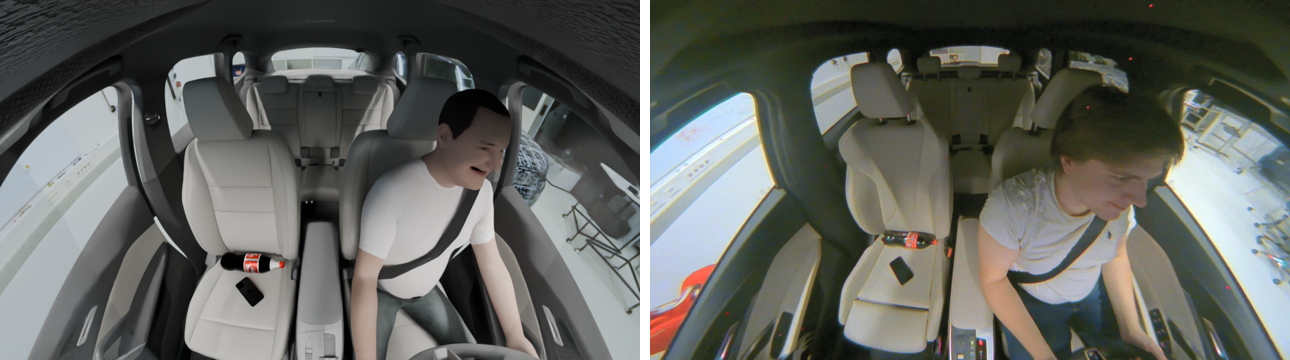

{'env': 'GARAGE',
 'driver_gender': 'MALE',
 'driver_tshirt_color': 'WHITE',
 'driver_emotion': 'HAPPY',
 'driver_phone': 'NO',
 'driver_safety_belt': 'YES',
 'passenger_codriver': 'NO',
 'passenger_codriver_gender': None,
 'passenger_codriver_tshirt_color': None,
 'passenger_codriver_emotion': None,
 'passenger_codriver_head_angle': None,
 'codriver_safety_belt': None,
 'passenger_rear_seat_left': 'NO',
 'passenger_rear_left_gender': None,
 'passenger_rear_left_tshirt_color': None,
 'passenger_rear_left_emotion': None,
 'passenger_rear_left_head_angle': None,
 'passenger_rear_left_safety_belt': None,
 'passenger_rear_seat_right': 'NO',
 'passenger_rear_right_gender': None,
 'passenger_rear_right_tshirt_color': None,
 'passenger_rear_right_emotion': None,
 'passenger_rear_right_head_angle': None,
 'passenger_rear_right_safety_belt': None,
 'phone_codriver_seat': 'YES',
 'phone_codriver_seat_color': 'BLACK',
 'colabottle_codriver_seat': 'YES',
 'colacan_codriver_seat': 'NO',
 'suitcase'

In [14]:
# Sanity check: look at one scene before writing any code.
if not scenes:
    print('No simulated scenes found. Run the setup and discovery cells after the dataset has been downloaded.')
else:
    example_stem = next(iter(scenes))
    example = scenes[example_stem]
    sim_image = Image.open(example['simulated']).convert('RGB')
    label = json.loads(example['label'].read_text())

    if reference_images:
        real_image = Image.open(reference_images[0]).convert('RGB')

        # Side-by-side preview, simulated then one real reference, scaled to the same height.
        height = 360
        sim_preview = sim_image.resize((int(sim_image.width * height / sim_image.height), height))
        real_preview = real_image.resize((int(real_image.width * height / real_image.height), height))
        preview = Image.new('RGB', (sim_preview.width + real_preview.width + 10, height), 'white')
        preview.paste(sim_preview, (0, 0))
        preview.paste(real_preview, (sim_preview.width + 10, 0))
        print(f'{example_stem}: simulated {sim_image.size} (left) vs real reference {real_image.size} (right)')
        display(preview)
    else:
        print(f'{example_stem}: simulated {sim_image.size}; no real reference images found')

    display(label)

## 4. 🎨 Implement your translation technique

Implement `translate` below. It receives:

- one simulated image 
- its label dict (optional, to condition on it)
- **kwargs (optional channel information, e.g., seg maps, canny edges, or depht maps) 

and must return one PIL image, that:

- keeps the same width, height, framing, and camera viewpoint as the simulated input
  (resizing is allowed but reduces fidelity/semantic scores — see `track_a/README.md`)
- does not crop, rotate, mirror, or change scene geometry
- does not add, remove, or move scene objects
- is RGB

The cell below wraps the `AppearanceTranslator` example from `test/example_custom_translator.py`
(lighting, color, texture, and exposure jitter that preserves scene structure), so the rest of
this notebook runs end to end and produces a non-trivial baseline submission. Replace the body
with your own model / pipeline, or swap in another `Translator` subclass from that file.

In [15]:
for path in (TRACK_A_DIR, TRACK_A_DIR / 'test'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from example_custom_translator import AppearanceTranslator

appearance_translator = AppearanceTranslator(intensity=0.5)


def translate(simulated_image: Image.Image, stem: str, label: dict, **kwargs) -> Image.Image:
    """Translate one simulated scene into a real-looking one."""
    # >>> REPLACE THIS WITH YOUR TECHNIQUE <<<
    # Uses the shipped AppearanceTranslator example; swap in your own model / pipeline.
    return appearance_translator.translate(simulated_image.convert('RGB'))

## 5. 💾 Write the submission folder

This builds `submissions/<team_name>/` with the four subfolders the evaluator expects: `simulated/` and `reference/` are copies of the provided data, `labels/` is a copy of the scene labels, and `generated/` holds your `translate()` output for every scene. The cell also measures translation time and writes `submissions/<team_name>/generation_times.json` (next to `generated/`, not inside it), as required by the efficiency metric. Do not hand-edit `simulated/` or `reference/` after this runs.

In [ ]:
for name in ('simulated', 'generated', 'reference', 'labels'):
    (SUBMISSION_DIR / name).mkdir(parents=True, exist_ok=True)

# Copy the real images as a separate reference distribution; they do not pair one-to-one with scenes.
for reference_path in reference_images:
    shutil.copy(reference_path, SUBMISSION_DIR / 'reference' / reference_path.name)

MAX_IMG = 10 # just for testing

total_generation_seconds = 0.0
for index, (stem, paths) in enumerate(scenes.items(), 1):
    if index < MAX_IMG:
        print(f'{index}/{len(scenes)}: {stem}')
        label = json.loads(paths['label'].read_text())
        simulated_image = Image.open(paths['simulated']).convert('RGB')
    
        started = time.perf_counter()
        generated_image = translate(simulated_image, stem, label)
        total_generation_seconds += time.perf_counter() - started
        generated_image.save(SUBMISSION_DIR / 'generated' / f'{stem}.png')
    
        shutil.copy(paths['simulated'], SUBMISSION_DIR / 'simulated' / paths['simulated'].name)
        shutil.copy(paths['label'], SUBMISSION_DIR / 'labels' / paths['label'].name)

generation_times = {
    'total_seconds': total_generation_seconds,
    'scenes': len(scenes),
    'hardware': {
        'platform': platform.platform(),
        'processor': platform.processor(),
        'python': platform.python_version(),
    },
}
# The timing file sits at the top level of the submission folder, next to generated/.
(SUBMISSION_DIR / 'generation_times.json').write_text(
    json.dumps(generation_times, indent=2, ensure_ascii=True)
)
print(f'\nWrote submission to {SUBMISSION_DIR}')
print(f'Total translation time: {total_generation_seconds:.3f} seconds')

## 6. ➡️ Next steps

Run `track_a_evaluator.ipynb` to score `submissions/<your_team_name>/`. Re-run this notebook (with your real `translate()` implementation) any time you want to regenerate your submission before scoring.